In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv("./data_science_job.csv")
df.sample(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
8071,19029,city_16,0.910,NaN,Has relevent experience,no_enrollment,Graduate,STEM,8.0,10000+,Pvt Ltd,7.0,0.0
17712,29311,city_16,0.910,Male,Has relevent experience,no_enrollment,Graduate,STEM,10.0,50-99,Pvt Ltd,32.0,0.0
8893,29419,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,15.0,NaN,NaN,244.0,0.0
9912,327,city_103,0.920,NaN,No relevent experience,no_enrollment,Graduate,STEM,2.0,500-999,Other,78.0,1.0
3435,30243,city_100,0.887,Male,Has relevent experience,no_enrollment,Graduate,STEM,9.0,<10,Pvt Ltd,43.0,1.0


In [22]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index     479
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
training_hours             766
target                       0
dtype: int64

In [23]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [24]:
cols = [col for col in df.columns if df[col].isnull().mean() < 0.05 and df[col].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [25]:
len(df[cols].dropna()) / len(df)

0.8968577095730244

In [26]:
new_df = df[cols].dropna()

In [27]:
new_df.shape, df.shape

((17182, 5), (19158, 13))

In [28]:
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [31]:
df[cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_development_index  18679 non-null  float64
 1   enrolled_university     18772 non-null  object 
 2   education_level         18698 non-null  object 
 3   experience              19093 non-null  float64
 4   training_hours          18392 non-null  float64
dtypes: float64(3), object(2)
memory usage: 748.5+ KB


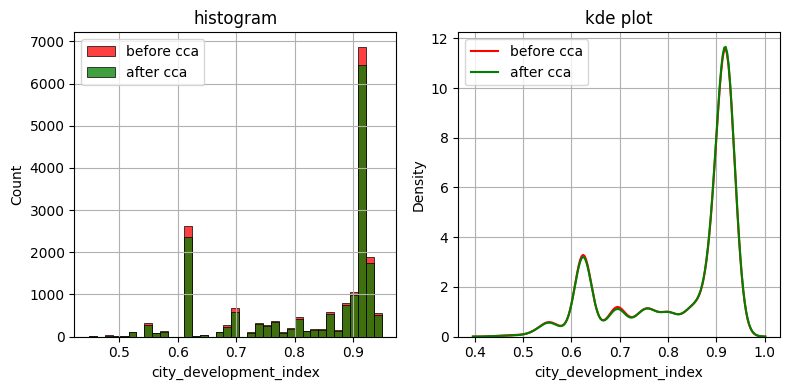

In [ ]:
plt.figure(figsize=(8,4))

# hist plot 
plt.subplot(1,2,1)
sns.histplot(df["city_development_index"], color="red", label="before cca") #before cca
sns.histplot(new_df["city_development_index"], color="green", label="after cca") # after cca 
plt.title("histogram")
plt.legend()
plt.grid()

# kde plot 
plt.subplot(1,2,2)
sns.kdeplot(df["city_development_index"], color="red", label="before cca") #before cca
sns.kdeplot(new_df["city_development_index"], color="green", label="after cca") # after cca 
plt.title("kde plot")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


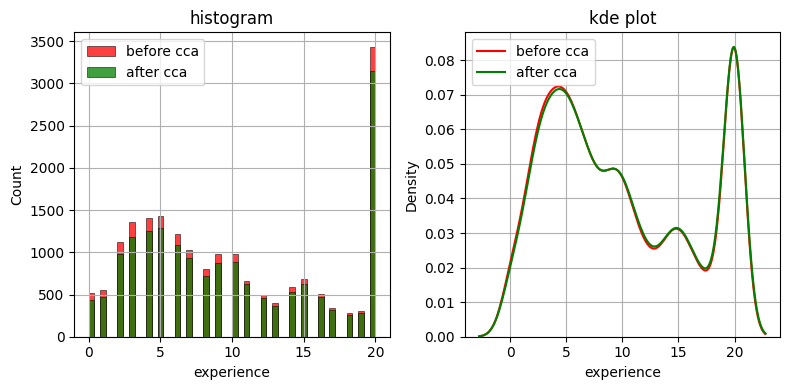

In [ ]:
plt.figure(figsize=(8,4))

# hist plot 
plt.subplot(1,2,1)
sns.histplot(df["experience"], color="red", label="before cca", bins=50) #before cca
sns.histplot(new_df["experience"], color="green", label="after cca", bins=50) #after cca
plt.title("histogram")
plt.legend()
plt.grid()

# kde plot 
plt.subplot(1,2,2)
sns.kdeplot(df["experience"], color="red", label="before cca") #before cca
sns.kdeplot(new_df["experience"], color="green", label="after cca") #after cca
plt.title("kde plot")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

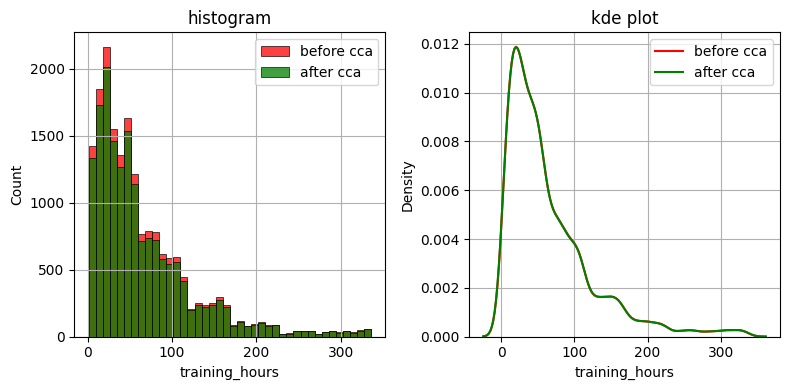

In [73]:
plt.figure(figsize=(8,4))

# hist plot 
plt.subplot(1,2,1)
sns.histplot(df["training_hours"], color="red", label="before cca", bins=40) #before cca
sns.histplot(new_df["training_hours"], color="green", label="after cca", bins=40) #after cca
plt.title("histogram")
plt.legend()
plt.grid()

# kde plot 
plt.subplot(1,2,2)
sns.kdeplot(df["training_hours"], color="red", label="before cca") #before cca
sns.kdeplot(new_df["training_hours"], color="green", label="after cca") #after cca
plt.title("kde plot")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [74]:
df[cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_development_index  18679 non-null  float64
 1   enrolled_university     18772 non-null  object 
 2   education_level         18698 non-null  object 
 3   experience              19093 non-null  float64
 4   training_hours          18392 non-null  float64
dtypes: float64(3), object(2)
memory usage: 748.5+ KB


In [81]:
temp = pd.concat([
    # ratio before cca
    df["enrolled_university"].value_counts() / len(df),
    # ratio after cca
    new_df["enrolled_university"].value_counts() / len(new_df)
], axis=1)

temp.columns = ["original", "cca"]
temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [82]:
temp = pd.concat([
    # ratio before cca
    df["education_level"].value_counts() / len(df),
    # ratio after cca
    new_df["education_level"].value_counts() / len(new_df)
], axis=1)

temp.columns = ["original", "cca"]
temp

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
